# Auto Finance Portfolio Analysis

This notebook generates synthetic data for an auto finance portfolio and then performs risk and loan-to-value (LTV) analysis to identify potential areas of concern.

In [ ]:
# Install Faker
!pip install faker -q

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
import random
from datetime import datetime, timedelta

# Set visualization style
sns.set_theme(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.5 MB/s eta 0:00:00


## Database Setup and Data Generation

This section sets up an in-memory SQLite database and populates it with synthetic data for borrowers, vehicle collateral and loan originations. The data generation includes various parameters like credit scores, income, vehicle details, loan amounts, interest rates and simulated delinquency days.

In [ ]:
fake = Faker()
conn = sqlite3.connect('auto_finance_portfolio.db')
cursor = conn.cursor()

# 1. Create Tables
cursor.executescript('''
    DROP TABLE IF EXISTS borrowers;
    DROP TABLE IF EXISTS vehicle_collateral;
    DROP TABLE IF EXISTS loan_originations;

    CREATE TABLE borrowers (
        borrower_id INTEGER PRIMARY KEY,
        credit_score INTEGER,
        annual_income REAL,
        employment_length_yrs INTEGER
    );

    CREATE TABLE vehicle_collateral (
        vehicle_id INTEGER PRIMARY KEY,
        make TEXT,
        model TEXT,
        model_year INTEGER,
        current_market_value REAL
    );

    CREATE TABLE loan_originations (
        loan_id INTEGER PRIMARY KEY,
        borrower_id INTEGER,
        vehicle_id INTEGER,
        origination_date DATE,
        loan_amount REAL,
        interest_rate REAL,
        term_months INTEGER,
        days_delinquent INTEGER,
        FOREIGN KEY (borrower_id) REFERENCES borrowers(borrower_id),
        FOREIGN KEY (vehicle_id) REFERENCES vehicle_collateral(vehicle_id)
    );
''')

# 2. Generate Data
num_records = 1500
vehicles = [
    ('Toyota', 'Camry', 2026), ('Toyota', 'Prius', 2026),
    ('Toyota', 'RAV4', 2025), ('Ford', 'F-150', 2024),
    ('Honda', 'Civic', 2025), ('Chevrolet', 'Silverado', 2024)
]

for i in range(1, num_records + 1):
    # Borrowers
    credit = random.randint(550, 820)
    income = round(random.uniform(35000, 150000), 2)
    emp_length = random.randint(0, 20)
    cursor.execute("INSERT INTO borrowers VALUES (?, ?, ?, ?)", (i, credit, income, emp_length))

    # Vehicles
    make, model, year = random.choice(vehicles)
    market_value = round(random.uniform(20000, 55000), 2)
    cursor.execute("INSERT INTO vehicle_collateral VALUES (?, ?, ?, ?, ?)", (i, make, model, year, market_value))

    # Loans
    orig_date = fake.date_between(start_date='-3y', end_date='today').strftime('%Y-%m-%d')
    loan_amt = round(market_value * random.uniform(0.8, 1.15), 2) # Simulating LTV variance

    # Rate based roughly on credit score
    if credit > 750: rate = random.uniform(3.0, 5.5)
    elif credit > 650: rate = random.uniform(5.5, 9.0)
    else: rate = random.uniform(9.0, 18.0)

    term = random.choice([48, 60, 72, 84])

    # Delinquency logic (lower credit = higher chance of delinquency)
    delinquent_days = 0
    if credit < 650 and random.random() < 0.3:
        delinquent_days = random.choice([30, 60, 90, 120])
    elif credit >= 650 and random.random() < 0.05:
        delinquent_days = random.choice([30, 60])

    cursor.execute("INSERT INTO loan_originations VALUES (?, ?, ?, ?, ?, ?, ?, ?)",
                   (i, i, i, orig_date, loan_amt, round(rate, 2), term, delinquent_days))

conn.commit()
print("Synthetic Corporate Auto Finance database successfully generated.")

Synthetic Corporate Auto Finance database successfully generated.


## Risk Analysis by Credit Tier

This query analyzes the portfolio's risk by segmenting loans into different credit tiers (Super Prime, Prime, Subprime and Deep Subprime) based on credit scores. It calculates the total number of loans, total portfolio value, severe delinquency count (60+ days delinquent) and the overall delinquency rate for each tier.

In [ ]:
query_risk = """
WITH CreditTiers AS (
    SELECT
        l.loan_id,
        l.loan_amount,
        l.days_delinquent,
        CASE
            WHEN b.credit_score >= 780 THEN '1_Super_Prime (780+)'
            WHEN b.credit_score BETWEEN 660 AND 779 THEN '2_Prime (660-779)'
            WHEN b.credit_score BETWEEN 600 AND 659 THEN '3_Subprime (600-659)'
            ELSE '4_Deep_Subprime (<600)'
        END AS credit_tier
    FROM loan_originations l
    JOIN borrowers b ON l.borrower_id = b.borrower_id
)
SELECT
    credit_tier,
    COUNT(loan_id) AS total_loans,
    SUM(loan_amount) AS total_portfolio_value,
    SUM(CASE WHEN days_delinquent >= 60 THEN 1 ELSE 0 END) AS severe_delinquency_count,
    ROUND(CAST(SUM(CASE WHEN days_delinquent >= 60 THEN 1 ELSE 0 END) AS FLOAT) / COUNT(loan_id) * 100, 2) AS delinquency_rate_pct
FROM CreditTiers
GROUP BY credit_tier
ORDER BY credit_tier;
"""

risk_df = pd.read_sql_query(query_risk, conn)
display(risk_df)

,credit_tier,total_loans,total_portfolio_value,severe_delinquency_count,delinquency_rate_pct
0,1_Super_Prime (780+),220,8104065.90,5,2.27
1,2_Prime (660-779),710,25462007.43,17,2.39
2,3_Subprime (600-659),331,12243294.46,56,16.92
3,4_Deep_Subprime (<600),239,9088680.96,55,23.01


## Loan-to-Value (LTV) and Interest Rate Analysis by Vehicle Model

This section focuses on the financial health related to vehicle collateral. It calculates the average Loan-to-Value (LTV) percentage and average interest rate (APR) for different vehicle makes and models. It also identifies the number of 'underwater' loans where the loan amount exceeds the current market value of the vehicle.

In [ ]:
query_ltv = """
SELECT
    v.make,
    v.model,
    COUNT(l.loan_id) as active_loans,
    ROUND(AVG(l.loan_amount / v.current_market_value) * 100, 2) AS avg_ltv_pct,
    SUM(CASE WHEN (l.loan_amount / v.current_market_value) > 1.0 THEN 1 ELSE 0 END) as underwater_loans,
    ROUND(AVG(l.interest_rate), 2) AS avg_apr
FROM loan_originations l
JOIN vehicle_collateral v ON l.vehicle_id = v.vehicle_id
GROUP BY v.make, v.model
ORDER BY underwater_loans DESC;
"""

ltv_df = pd.read_sql_query(query_ltv, conn)
display(ltv_df)

,make,model,active_loans,avg_ltv_pct,underwater_loans,avg_apr
0,Ford,F-150,268,97.81,115,8.59
1,Chevrolet,Silverado,256,98.08,114,8.71
2,Honda,Civic,252,97.30,110,8.35
3,Toyota,Camry,243,97.54,107,8.29
4,Toyota,Prius,225,97.83,100,8.58
5,Toyota,RAV4,256,96.45,100,8.95


## Visualizing Portfolio Risk

This section presents two visualizations:

1.  **Delinquency Rates by Credit Tier:** A bar chart showing the 60+ day delinquency rate for each credit tier, highlighting higher risk segments.
2.  **Risk Matrix: LTV vs. Interest Rate by Model:** A scatter plot illustrating the relationship between average LTV and average APR for different vehicle models, with the size of the points indicating the number of 'underwater' loans. A red dashed line indicates the 100% LTV threshold.

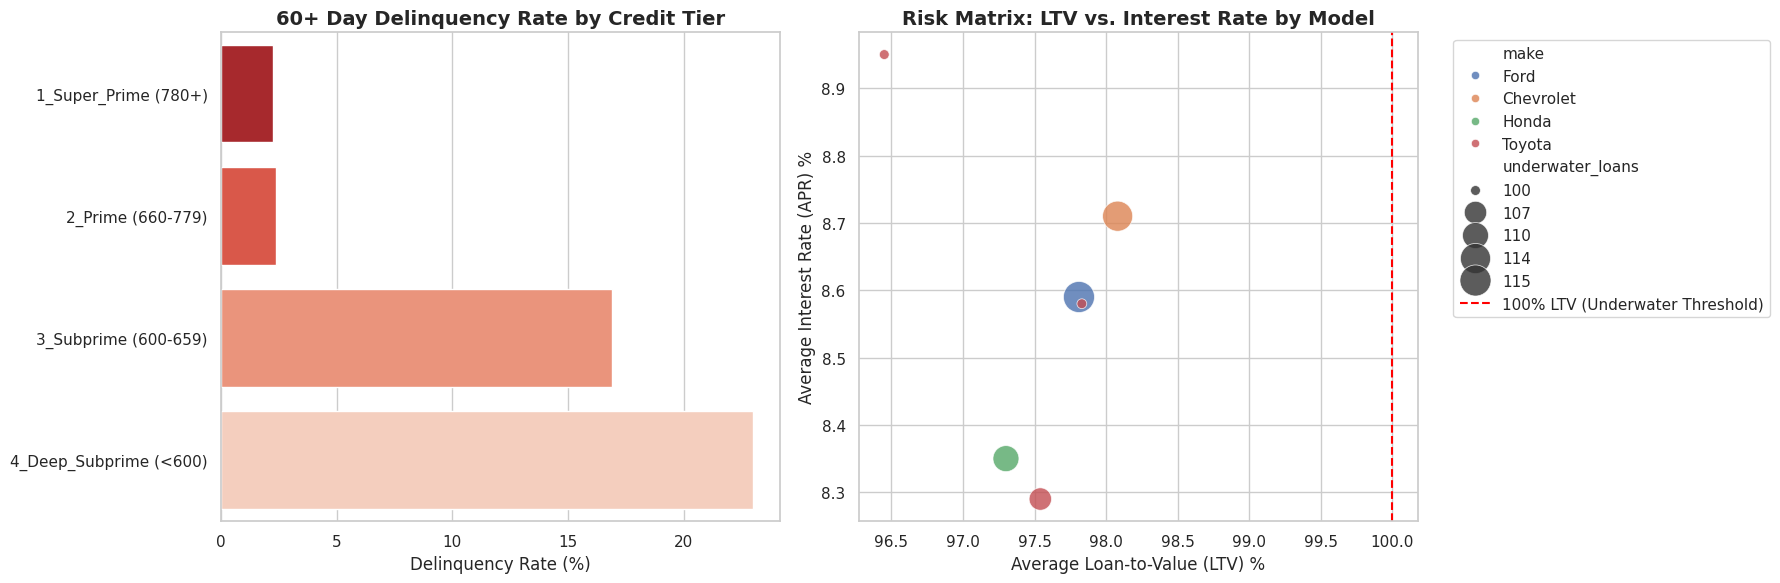

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1: Delinquency Rates by Credit Tier
sns.barplot(
    data=risk_df,
    x='delinquency_rate_pct',
    y='credit_tier',
    palette='Reds_r',
    hue='credit_tier',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('60+ Day Delinquency Rate by Credit Tier', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Delinquency Rate (%)')
axes[0].set_ylabel('')

# Chart 2: LTV Exposure by Vehicle Model
sns.scatterplot(
    data=ltv_df,
    x='avg_ltv_pct',
    y='avg_apr',
    size='underwater_loans',
    sizes=(50, 500),
    hue='make',
    alpha=0.8,
    ax=axes[1]
)
axes[1].axvline(100, color='red', linestyle='--', label='100% LTV (Underwater Threshold)')
axes[1].set_title('Risk Matrix: LTV vs. Interest Rate by Model', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Loan-to-Value (LTV) %')
axes[1].set_ylabel('Average Interest Rate (APR) %')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Summary and Business Recommendations

### Summary

This analysis generated a synthetic auto finance portfolio and explored key risk metrics. We observed a clear correlation between credit tiers and delinquency rates, with 'Deep Subprime' borrowers showing significantly higher 60+ day delinquency rates. Additionally, the Loan-to-Value (LTV) analysis revealed varying levels of 'underwater' loans across different vehicle models, indicating potential collateral risks.

### Business Recommendations

1.  **Refine Lending Criteria for Subprime Tiers:** Given the elevated delinquency rates in the 'Subprime' and 'Deep Subprime' tiers, consider tightening lending criteria, increasing interest rates or requiring larger down payments for these segments to mitigate risk.
2.  **Monitor High LTV Models:** Continuously monitor vehicle models with a high proportion of 'underwater' loans. These vehicles represent higher risk in the event of default, as the outstanding loan amount exceeds the collateral's value. Adjust LTV caps or increase reserve allocations for these specific models.
3.  **Proactive Delinquency Management:** Implement more aggressive and proactive strategies for borrowers approaching 60 days delinquent, especially within the higher-risk credit tiers. This could include early intervention calls, flexible repayment plans or targeted communication campaigns.
4.  **Diversify Portfolio:** While not directly analyzed, consider strategies to diversify the portfolio across various credit tiers and vehicle types to spread risk and reduce over-reliance on high-risk segments or models.
5.  **Data-Driven Pricing:** Use the insights from LTV and interest rate analysis to refine pricing models, ensuring interest rates adequately compensate for the inherent risks associated with specific vehicle models and borrower profiles.